In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


In [3]:
np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("insurance.csv")

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.970,3,no,northwest,10600.548
1334,18,female,31.920,0,no,northeast,2205.981
1335,18,female,36.850,0,no,southeast,1629.833
1336,21,female,25.800,0,no,southwest,2007.945
1337,61,female,29.070,0,yes,northwest,29141.360


In [9]:
df.shape

(1338, 7)

In [12]:
num_cols = ["age", "bmi", "children", "charges"]
cat_cols = ["sex", "smoker", "region"]

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'bmi', 'children', 'charges']
Categorical columns: ['sex', 'smoker', 'region']


In [15]:
print("Shape:"+ str(df.shape))
print("\nColumn names:\n", df.columns.tolist())

print("-"*50)

print("\nData types:")
print(df.dtypes)

print("-"*50)

print("\nUnique values per column:")
print(df.nunique())

Shape:(1338, 7)

Column names:
 ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
--------------------------------------------------

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
--------------------------------------------------

Unique values per column:
age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


In [16]:
print("First pass info:")
print(df.info())

First pass info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [17]:
df[num_cols].describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


In [18]:
df.isnull().sum()   


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})

print("Missing values summary:")

Missing values summary:


In [21]:
for col in df.columns:
    print(df[col].value_counts())


age
18    69
19    68
50    29
51    29
47    29
46    29
45    29
20    29
48    29
52    29
22    28
49    28
54    28
53    28
21    28
26    28
24    28
25    28
28    28
27    28
23    28
43    27
29    27
30    27
41    27
42    27
44    27
31    27
40    27
32    26
33    26
56    26
34    26
55    26
57    26
37    25
59    25
58    25
36    25
38    25
35    25
39    25
61    23
60    23
63    23
62    23
64    22
Name: count, dtype: int64
sex
male      676
female    662
Name: count, dtype: int64
bmi
32.300    13
28.310     9
30.495     8
30.875     8
31.350     8
          ..
46.200     1
23.800     1
44.770     1
32.120     1
30.970     1
Name: count, Length: 548, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
charges
1639.563     2
16884.924    1
29330.983    1
222

In [22]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:", num_duplicates)
print("Duplicated row:\n",df[duplicate_mask])

Number of duplicate rows: 1
Duplicated row:
      age   sex    bmi  children smoker     region  charges
581   19  male 30.590         0     no  northwest 1639.563


In [23]:
df_no_duplicates = df.drop_duplicates()
print("Shape after dropping duplicates:", df_no_duplicates.shape)

Shape after dropping duplicates: (1337, 7)


In [24]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [25]:
expected_types = {
    "age": "int64",
    "sex": "object",
    "bmi": "float64",
    "children": "int64",
    "smoker": "object",
    "region": "object",
    "charges": "float64"
}

print("Data type validation:")
for col, expected in expected_types.items():
    if col in df.columns:
        actual = df[col].dtype
        print(f"{col}: actual={actual}, expected={expected}")

Data type validation:
age: actual=int64, expected=int64
sex: actual=object, expected=object
bmi: actual=float64, expected=float64
children: actual=int64, expected=int64
smoker: actual=object, expected=object
region: actual=object, expected=object
charges: actual=float64, expected=float64


In [26]:
n_rows = len(df)
nunique = df.nunique()

constant_cols = nunique[nunique == 1].index.tolist()
print("Constant columns:", constant_cols)

quasi_constant_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.95 and col not in constant_cols:
        quasi_constant_cols.append(col)

print("Quasi constant columns (top value more than 95 percent):", quasi_constant_cols)

Constant columns: []
Quasi constant columns (top value more than 95 percent): []


In [27]:
id_like_cols = []

for col in df.columns:
    if df[col].nunique(dropna=False) == n_rows:
        id_like_cols.append(col)

print("ID like columns:", id_like_cols)

ID like columns: []


In [28]:
zero_share = {}

for col in num_cols:
    zero_share[col] = (df[col] == 0).mean()

zero_share_series = pd.Series(zero_share).sort_values(ascending=False)
zero_share_series

high_zero_threshold = 0.8  # 80 percent or more zeros
high_zero_cols = zero_share_series[zero_share_series >= high_zero_threshold]
print("Numeric columns with many zeros:")
high_zero_cols

Numeric columns with many zeros:


Series([], dtype: float64)

In [29]:
print("Summary statistics:")
df[num_cols].describe()

Summary statistics:


,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


In [30]:
print("Mean:")
print(df[num_cols].mean())


print("Median:")
print(df[num_cols].median())


print("Mode:")
print(df[num_cols].mode().iloc[0])

Mean:
age           39.207
bmi           30.663
children       1.095
charges    13270.422
dtype: float64
Median:
age          39.000
bmi          30.400
children      1.000
charges    9382.033
dtype: float64
Mode:
age          18.000
bmi          32.300
children      0.000
charges    1639.563
Name: 0, dtype: float64


In [31]:
print("Variance:")
print(df[num_cols].var())

print("Standard Deviation:")
print(df[num_cols].std())

Variance:
age              197.401
bmi               37.188
children           1.453
charges    146652372.153
dtype: float64
Standard Deviation:
age           14.050
bmi            6.098
children       1.205
charges    12110.011
dtype: float64


In [32]:
print("Skewness:")
print(df[num_cols].skew())

print("Kurtosis:")
print(df[num_cols].kurtosis())

Skewness:
age        0.056
bmi        0.284
children   0.938
charges    1.516
dtype: float64
Kurtosis:
age        -1.245
bmi        -0.051
children    0.202
charges     1.606
dtype: float64


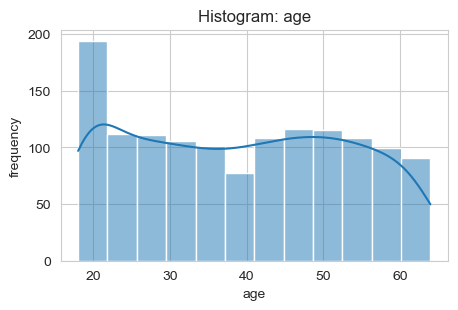

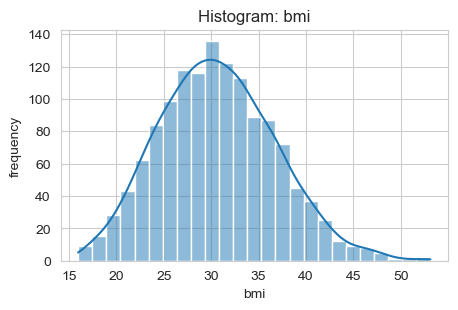

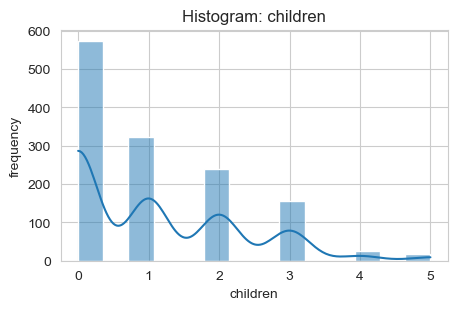

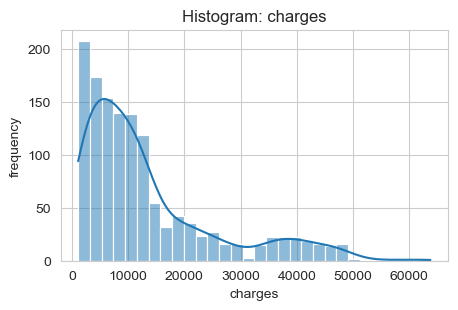

In [33]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

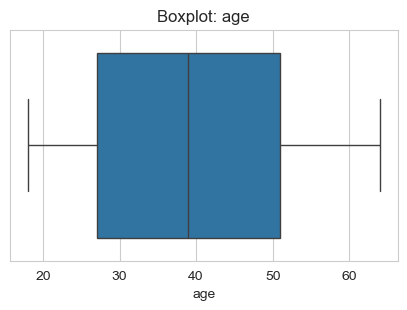

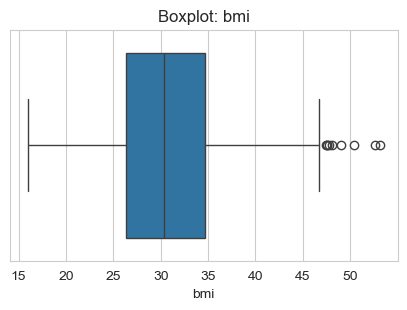

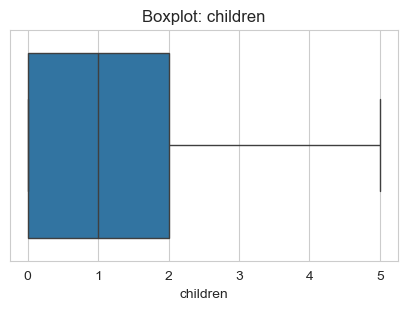

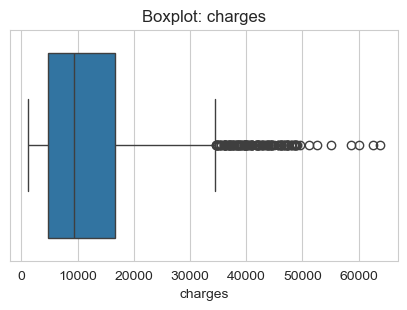

In [34]:
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

In [35]:
print(cat_cols)

['sex', 'smoker', 'region']


In [36]:
df[cat_cols].head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [38]:
for col in cat_cols:
    print(f"Frequency table for {col}")
    print(df[col].value_counts())
    print(f"Proportion for {col}")
    print(df[col].value_counts(normalize=True))

Frequency table for sex
sex
male      676
female    662
Name: count, dtype: int64
Proportion for sex
sex
male     0.505
female   0.495
Name: proportion, dtype: float64
Frequency table for smoker
smoker
no     1064
yes     274
Name: count, dtype: int64
Proportion for smoker
smoker
no    0.795
yes   0.205
Name: proportion, dtype: float64
Frequency table for region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Proportion for region
region
southeast   0.272
southwest   0.243
northwest   0.243
northeast   0.242
Name: proportion, dtype: float64


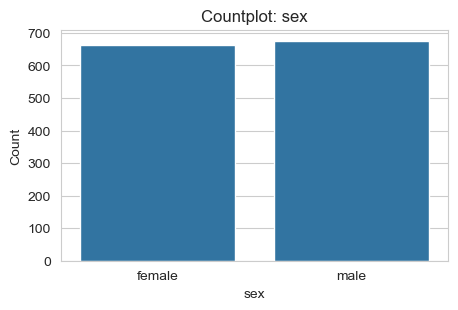

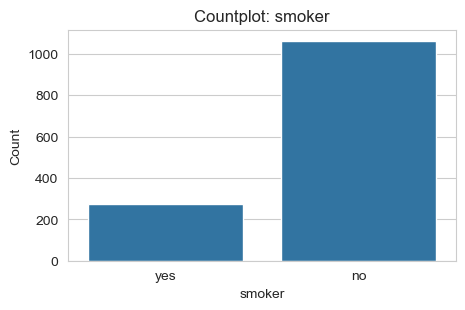

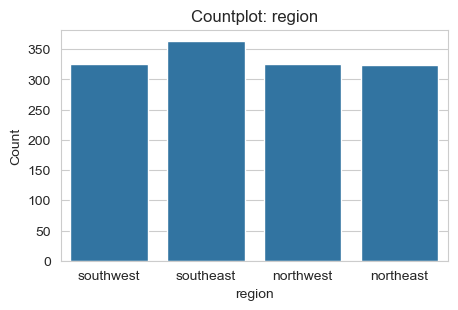

In [39]:
for col in cat_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [40]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [41]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

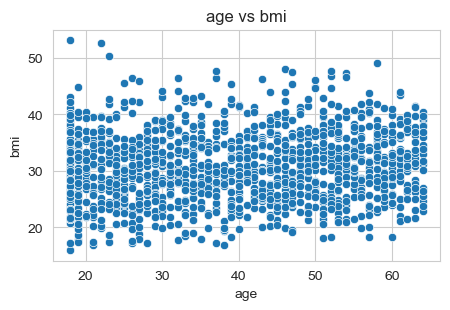

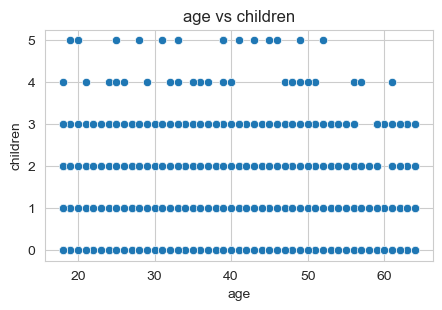

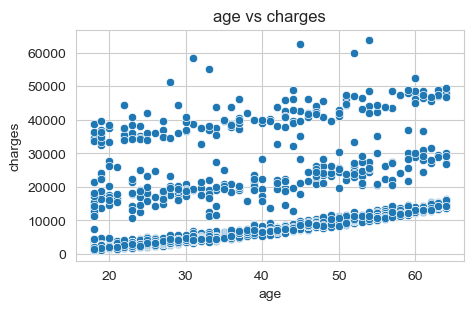

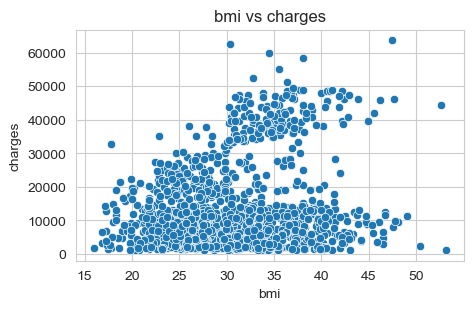

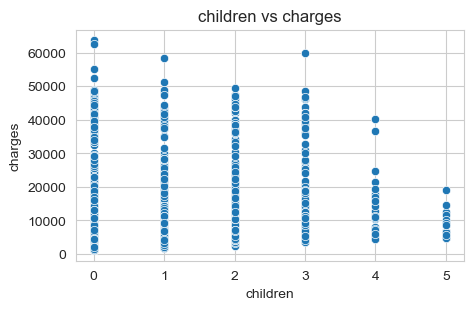

In [42]:
num_pairs = [
    ("age", "bmi"),
    ("age", "children"),
    ("age", "charges"),
    ("bmi", "charges"),
    ("children", "charges")
]

for x, y in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [43]:
print("Correlation Matrix")
df[num_cols].corr()

Correlation Matrix


,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


In [44]:
print("Pearson Correlation with fare:")
for col in num_cols:
    if col != "age":
        r, p = pearsonr(df[col], df["age"])
        print(f"{col} vs age: r={r:.3f}; p={p:.3f}")


Pearson Correlation with fare:
bmi vs age: r=0.109; p=0.000
children vs age: r=0.042; p=0.120
charges vs age: r=0.299; p=0.000


In [45]:
print(num_cols)
print(cat_cols)

['age', 'bmi', 'children', 'charges']
['sex', 'smoker', 'region']


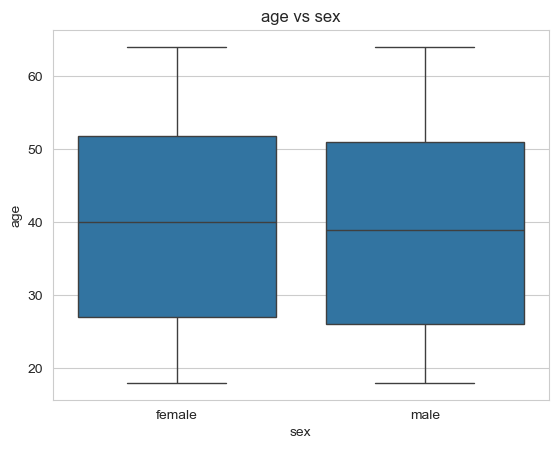

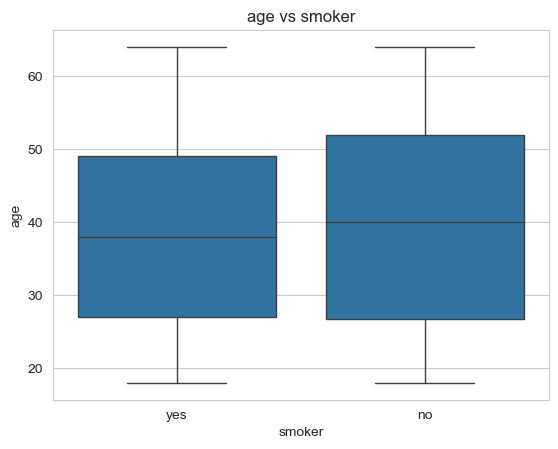

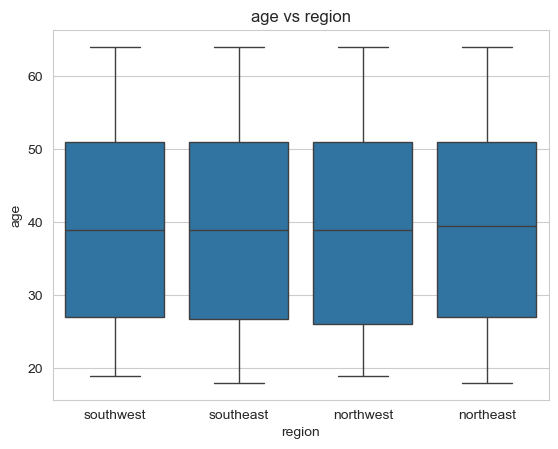

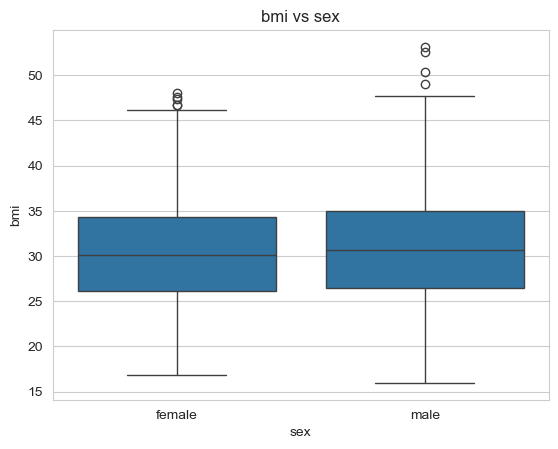

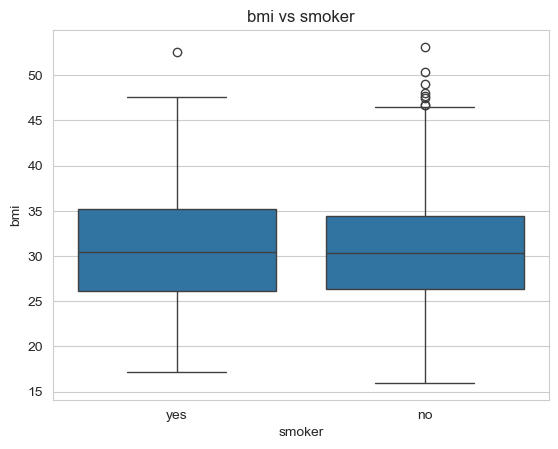

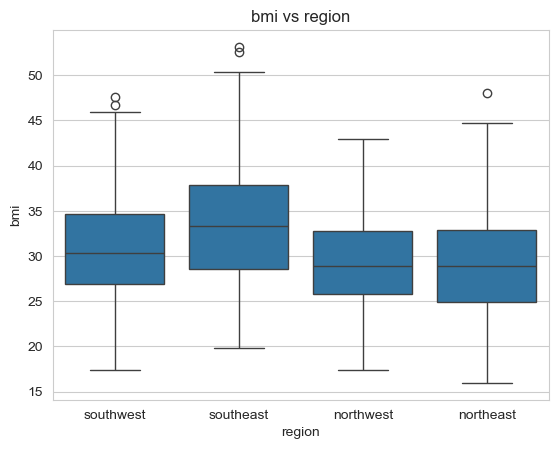

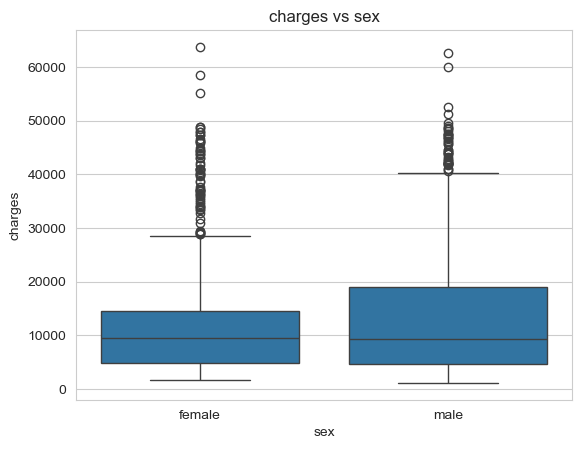

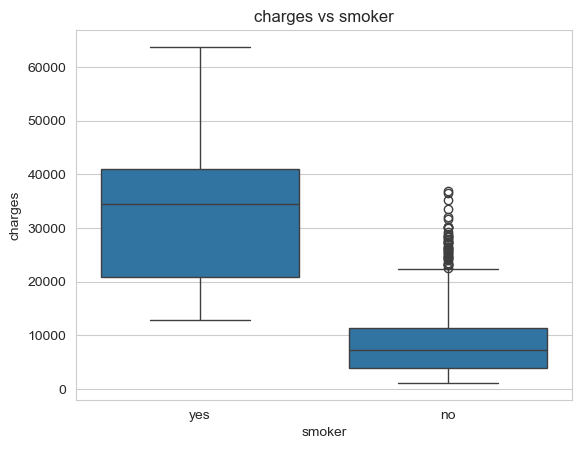

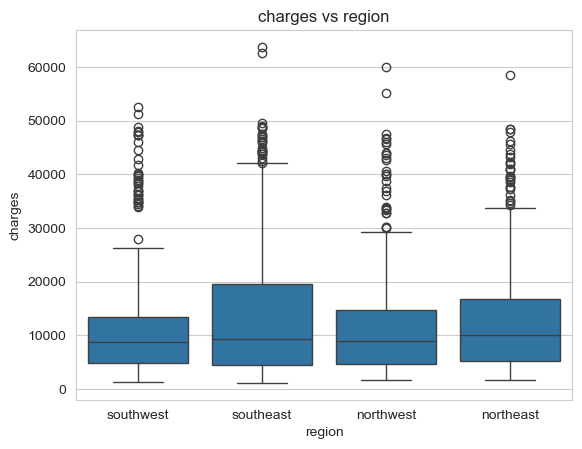

In [46]:
num_for_box = ["age", "bmi", "charges"]
cat_for_box = ["sex", "smoker", "region"]

for num in num_for_box:
    for cat in cat_for_box:
        plt.Figure(figsize=(5,3))
        sns.boxplot(x=df[cat], y=df[num])
        plt.title(f"{num} vs {cat}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

In [47]:
df[num_cols + ["sex"]].groupby("sex").mean()

,age,bmi,children,charges
sex,,,,
female,39.503,30.378,1.074,12569.579
male,38.917,30.943,1.115,13956.751


In [48]:
for category in ["sex", "smoker", "region"]:
    print(df[num_cols + [category]].groupby(category).mean())

          age    bmi  children   charges
sex                                     
female 39.503 30.378     1.074 12569.579
male   38.917 30.943     1.115 13956.751
          age    bmi  children   charges
smoker                                  
no     39.385 30.652     1.090  8434.268
yes    38.515 30.708     1.113 32050.232
             age    bmi  children   charges
region                                     
northeast 39.269 29.174     1.046 13406.385
northwest 39.197 29.200     1.148 12417.575
southeast 38.940 33.356     1.049 14735.411
southwest 39.455 30.597     1.142 12346.937


In [49]:
print("Crosstab: sex vs smoker")
print(pd.crosstab(df["sex"], df["smoker"]))

print("Crosstab: smoker vs region")
print(pd.crosstab(df["smoker"], df["region"]))

Crosstab: sex vs smoker
smoker   no  yes
sex             
female  547  115
male    517  159
Crosstab: smoker vs region
region  northeast  northwest  southeast  southwest
smoker                                            
no            257        267        273        267
yes            67         58         91         58


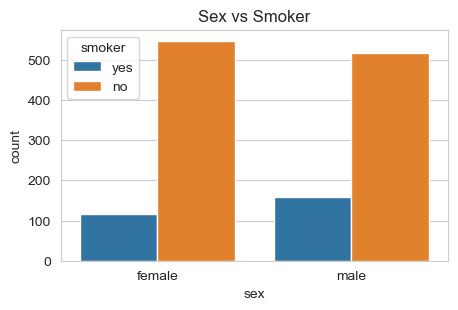

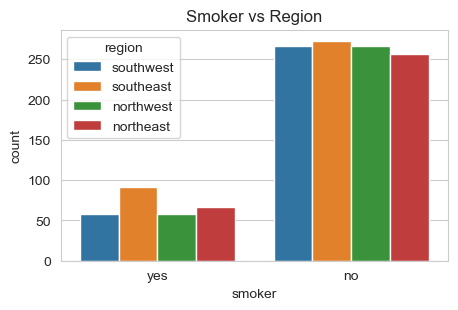

In [50]:
plt.figure(figsize=(5,3))
sns.countplot(x=df["sex"], hue=df["smoker"])
plt.title("Sex vs Smoker")
plt.show()


plt.figure(figsize=(5,3))
sns.countplot(x=df["smoker"], hue=df["region"])
plt.title("Smoker vs Region")
plt.show()

In [51]:
print("Numerical Columns", num_cols)
print("Categorical Columns", cat_cols)

Numerical Columns ['age', 'bmi', 'children', 'charges']
Categorical Columns ['sex', 'smoker', 'region']


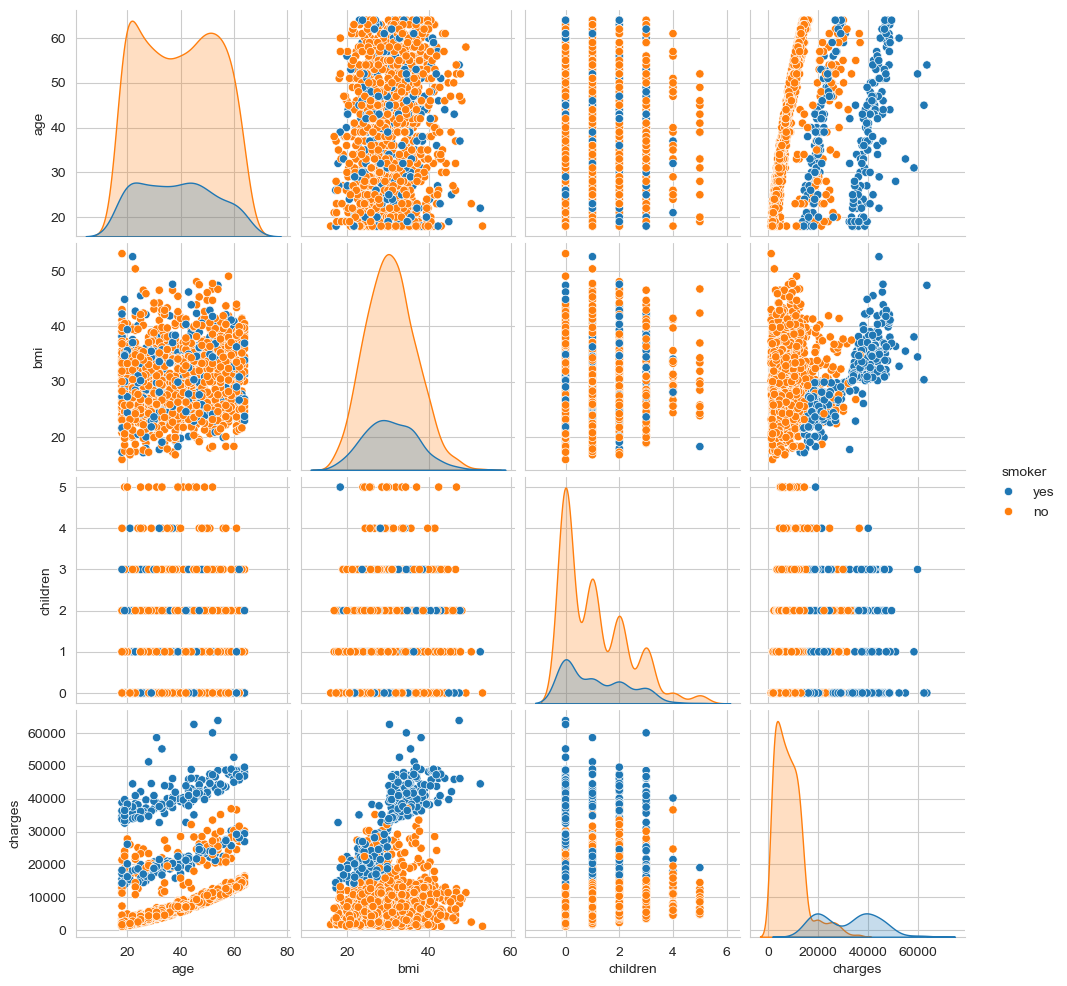

In [52]:
pairplot_cols = num_cols + ["smoker"]

df_pair = df[pairplot_cols].dropna()

sns.pairplot(df_pair, hue="smoker")
plt.show()

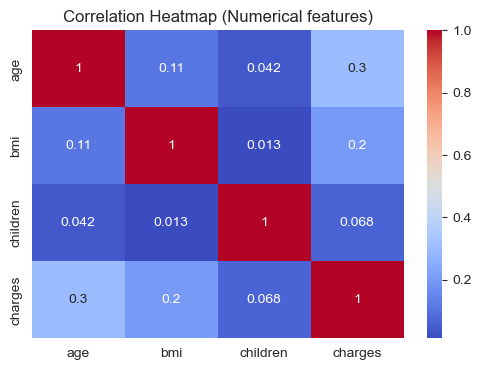

In [53]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical features)")
plt.show()

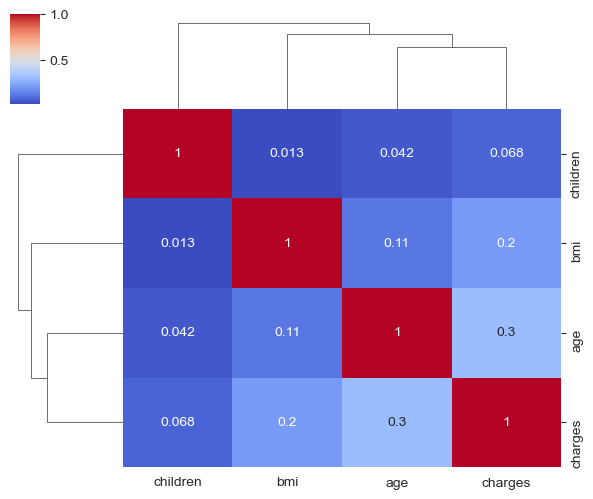

In [54]:
sns.clustermap(df[num_cols].corr(), annot=True, cmap="coolwarm", figsize=(6,5))
plt.show()

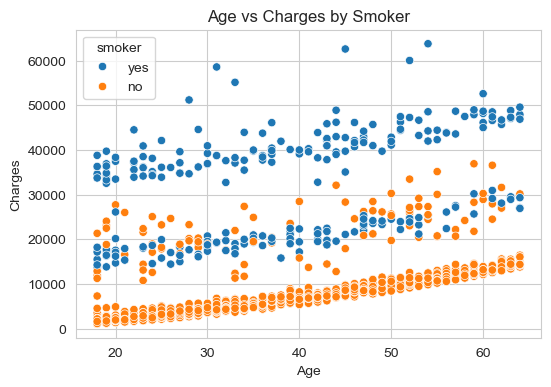

In [55]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"], y=df["charges"], hue=df["smoker"])
plt.title("Age vs Charges by Smoker")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

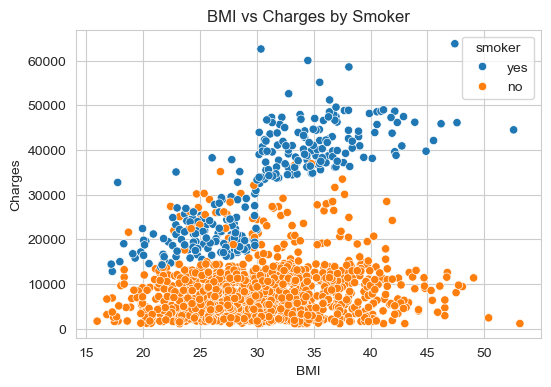

In [57]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["bmi"], y=df["charges"], hue=df["smoker"])
plt.title("BMI vs Charges by Smoker")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

In [59]:
df.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [60]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [61]:
print("Numerical Columns", num_cols)
print("Categorical Columns", cat_cols)

Numerical Columns ['age', 'bmi', 'children', 'charges']
Categorical Columns ['sex', 'smoker', 'region']


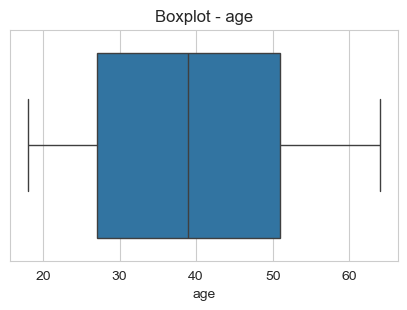

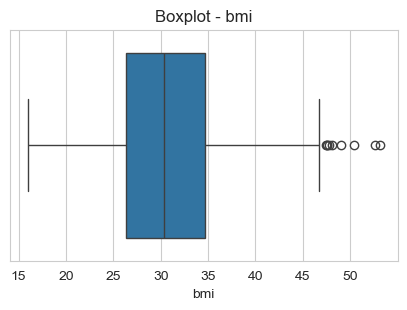

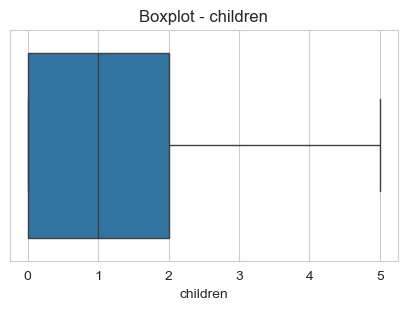

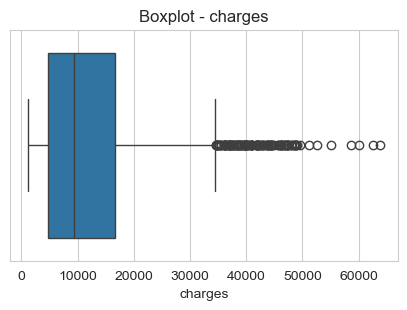

In [62]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

In [63]:
def iqr_bounds(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    return lower_bound, upper_bound, iqr

In [64]:
for col in num_cols:
    col_clean = df[col].dropna()
    lower, upper, iqr = iqr_bounds(col_clean)
    outliers_mask = (col_clean < lower) | (col_clean > upper)
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f" IQR method for {col}:")
    print(f" Q1 - 1.5*IQR: {lower:.2f}")
    print(f" Q3 + 1.5*IQR: {upper:.2f}")
    print(f" IQR: {iqr:.2f}")
    print(f" Outliers: {num_outliers} out of {total}")

 IQR method for age:
 Q1 - 1.5*IQR: -9.00
 Q3 + 1.5*IQR: 87.00
 IQR: 24.00
 Outliers: 0 out of 1338
 IQR method for bmi:
 Q1 - 1.5*IQR: 13.70
 Q3 + 1.5*IQR: 47.29
 IQR: 8.40
 Outliers: 9 out of 1338
 IQR method for children:
 Q1 - 1.5*IQR: -3.00
 Q3 + 1.5*IQR: 5.00
 IQR: 2.00
 Outliers: 0 out of 1338
 IQR method for charges:
 Q1 - 1.5*IQR: -13109.15
 Q3 + 1.5*IQR: 34489.35
 IQR: 11899.63
 Outliers: 139 out of 1338


In [ ]:
z_threshold = 3.0

for col in num_cols:
    col_clean = df[col].dropna()
    mean = col_clean.mean()
    std = col_clean.std()

    z_scores = (col_clean - mean) / std
    outliers_mask = np.abs(z_scores) > z_threshold
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f" Z score method for {col}:")
    print(f" Mean: {mean:.2f}, Std: {std:.2f}")
    print(f" Threshold: |Z| > {z_threshold}")
    print(f" Outliers: {num_outliers} out of {total}")


Z score method for age:
 Mean: 39.21, Std: 14.05
 Threshold: |Z| > 3.0
 Outliers: 0 out of 1338

Z score method for bmi:
 Mean: 30.66, Std: 6.10
 Threshold: |Z| > 3.0
 Outliers: 4 out of 1338

Z score method for children:
 Mean: 1.09, Std: 1.21
 Threshold: |Z| > 3.0
 Outliers: 18 out of 1338

Z score method for charges:
 Mean: 13270.42, Std: 12110.01
 Threshold: |Z| > 3.0
 Outliers: 7 out of 1338


In [67]:
charges_clean = df["charges"].dropna()
charges_lower, charges_upper, charges_iqr = iqr_bounds(charges_clean)

charges_inliers = charges_clean[(charges_clean >= charges_lower) & (charges_clean <= charges_upper)]

print(" stats with outliers:")
print(f" Count: {charges_clean.shape[0]}")
print(f" Mean: {charges_clean.mean():.2f}")
print(f" Median: {charges_clean.median():.2f}")
print(f" Min: {charges_clean.min():.2f}, Max: {charges_clean.max():.2f}")


print(" stats after removing IQR outliers:")
print(f" Count: {charges_inliers.shape[0]}")
print(f" Mean: {charges_inliers.mean():.2f}")
print(f" Median: {charges_inliers.median():.2f}")
print(f" Min: {charges_inliers.min():.2f}, Max: {charges_inliers.max():.2f}")

 stats with outliers:
 Count: 1338
 Mean: 13270.42
 Median: 9382.03
 Min: 1121.87, Max: 63770.43
 stats after removing IQR outliers:
 Count: 1199
 Mean: 9927.75
 Median: 8410.05
 Min: 1121.87, Max: 34472.84
